# 02 - Sticker orientation

Stage 2 of 3: given a padded crop around the sticker, predict how far off
horizontal it is.

The crop comes from the *ground-truth* box, but position/scale-jittered
(`OrientationDataset`'s default `jitter=True`, via `geometry.jitter_bbox`) to
resemble what stage 1's actual (imperfect, ~0.7 mean IoU) predictions produce
- training only against pixel-perfect ground-truth crops left this stage
fragile to that real imprecision when chained end-to-end (see
`04_end_to_end_pipeline.ipynb`). The target angle itself is unaffected by the
jitter, since rotation doesn't depend on exactly where the crop's edges land.

Angle is encoded as `(sin, cos)` rather than a raw degree value - a
0deg/360deg boundary would otherwise be a huge, discontinuous jump for the
regression loss to deal with even though the two angles are visually
identical. `geometry.sin_cos_to_angle` recovers the angle via `atan2`.

Note on training dynamics: this model's loss often sits flat near its
starting value for several epochs before suddenly breaking through - typical
of a `(sin, cos)`-normalized regression head needing a few epochs to escape a
"predict a constant unit vector" local optimum. Don't stop early just because
the first handful of epochs look flat.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise RuntimeError("Could not locate the vision-ml project root from " + str(start))


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/lroland/Projects/github.com/distribution-center/vision-ml')

In [2]:
import contextlib
import json
import math
import random

import matplotlib.pyplot as plt
import mlflow
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader

from src import datasets, geometry, models, settings, tracking

random.seed(0)
torch.manual_seed(0)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DEVICE


'mps'

## Load data

In [3]:
records = datasets.load_manifest(settings.RAW_DIR / "manifest.jsonl")
splits = json.loads((settings.RAW_DIR / "splits.json").read_text())


def _records_for(skus):
    sku_set = set(skus)
    return [r for r in records if r["sku"] in sku_set]


train_records = _records_for(splits["train_skus"])
val_records = _records_for(splits["val_skus"])
print(f"train: {len(train_records)} images   val: {len(val_records)} images")

BATCH_SIZE = 32
PAD_FRAC = 0.2
train_ds = datasets.OrientationDataset(train_records, settings.RAW_DIR, pad_frac=PAD_FRAC)
val_ds = datasets.OrientationDataset(val_records, settings.RAW_DIR, pad_frac=PAD_FRAC)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


train: 5440 images   val: 640 images


## Train

MSE on the unit `(sin, cos)` vector, but the metric worth actually reading is mean absolute angular error in degrees (shortest-arc, via `atan2` of the difference).

In [4]:
def angular_error_degrees(pred: torch.Tensor, target: torch.Tensor) -> float:
    pred_angle = torch.atan2(pred[:, 0], pred[:, 1])
    target_angle = torch.atan2(target[:, 0], target[:, 1])
    diff = torch.atan2(torch.sin(pred_angle - target_angle), torch.cos(pred_angle - target_angle))
    return diff.abs().mean().item() * 180 / math.pi


In [5]:
EPOCHS = 30
LR = 1e-3

model = models.OrientationNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

tracking.configure_tracking("orientation")
run_ctx = mlflow.start_run(run_name="orientation") if tracking.is_enabled() else contextlib.nullcontext()

history = {"train_loss": [], "val_loss": [], "val_angle_error_deg": []}
best_val_angle_error = float("inf")
best_state_dict = None

with run_ctx:
    if tracking.is_enabled():
        mlflow.log_params({"epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR, "pad_frac": PAD_FRAC, "model": "OrientationNet"})

    for epoch in range(EPOCHS):
        model.train()
        train_loss_total = 0.0
        for images, targets in train_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            preds = model(images)
            loss = loss_fn(preds, targets)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item() * images.size(0)
        train_loss = train_loss_total / len(train_ds)

        model.eval()
        val_loss_total = 0.0
        val_angle_total = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                preds = model(images)
                val_loss_total += loss_fn(preds, targets).item() * images.size(0)
                val_angle_total += angular_error_degrees(preds, targets) * images.size(0)
        val_loss = val_loss_total / len(val_ds)
        val_angle_error = val_angle_total / len(val_ds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_angle_error_deg"].append(val_angle_error)
        is_best = val_angle_error < best_val_angle_error
        if is_best:
            best_val_angle_error = val_angle_error
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch + 1:2d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_angle_error={val_angle_error:.2f}deg{'  (best)' if is_best else ''}")

        if tracking.is_enabled():
            mlflow.log_metrics({"train_loss": train_loss, "val_loss": val_loss, "val_angle_error_deg": val_angle_error}, step=epoch)

    # Save the best-val-angle-error epoch's weights, not just the last epoch - see the same
    # reasoning in 01_sticker_localization.ipynb.
    model.load_state_dict(best_state_dict)
    settings.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint_path = settings.MODELS_DIR / "orientation.pt"
    torch.save(model.state_dict(), checkpoint_path)
    if tracking.is_enabled():
        mlflow.log_metric("best_val_angle_error_deg", best_val_angle_error)
        mlflow.log_artifact(str(checkpoint_path))

print(f"saved {checkpoint_path} (best val_angle_error={best_val_angle_error:.2f}deg)")


epoch  1/30  train_loss=1.0014  val_loss=0.9523  val_angle_error=86.36deg  (best)


epoch  2/30  train_loss=0.9928  val_loss=0.9742  val_angle_error=88.05deg


epoch  3/30  train_loss=0.8678  val_loss=0.9096  val_angle_error=83.79deg  (best)


epoch  4/30  train_loss=0.6893  val_loss=0.6576  val_angle_error=65.72deg  (best)


epoch  5/30  train_loss=0.4603  val_loss=0.7045  val_angle_error=68.77deg


...

epoch 26/30  train_loss=0.0171  val_loss=0.0372  val_angle_error=10.16deg


epoch 27/30  train_loss=0.0195  val_loss=0.0076  val_angle_error=5.57deg


epoch 28/30  train_loss=0.0108  val_loss=0.0173  val_angle_error=9.00deg


epoch 29/30  train_loss=0.0265  val_loss=0.0084  val_angle_error=6.03deg


epoch 30/30  train_loss=0.0077  val_loss=0.0040  val_angle_error=4.12deg  (best)
saved /Users/lroland/Projects/github.com/distribution-center/vision-ml/data/models/orientation.pt (best val_angle_error=4.12deg)


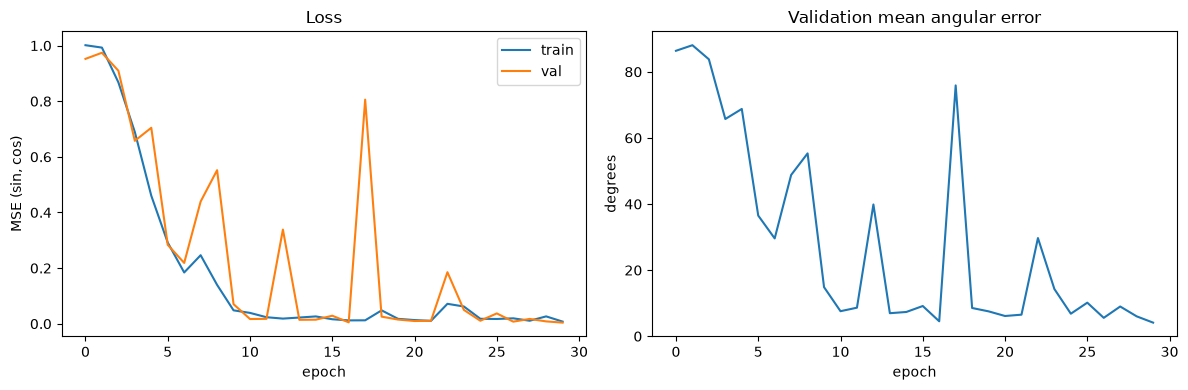

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_xlabel("epoch"); ax1.set_ylabel("MSE (sin, cos)"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(history["val_angle_error_deg"])
ax2.set_xlabel("epoch"); ax2.set_ylabel("degrees"); ax2.set_title("Validation mean angular error")
plt.tight_layout()
plt.show()


## Qualitative check: does the predicted correction actually straighten the crop?

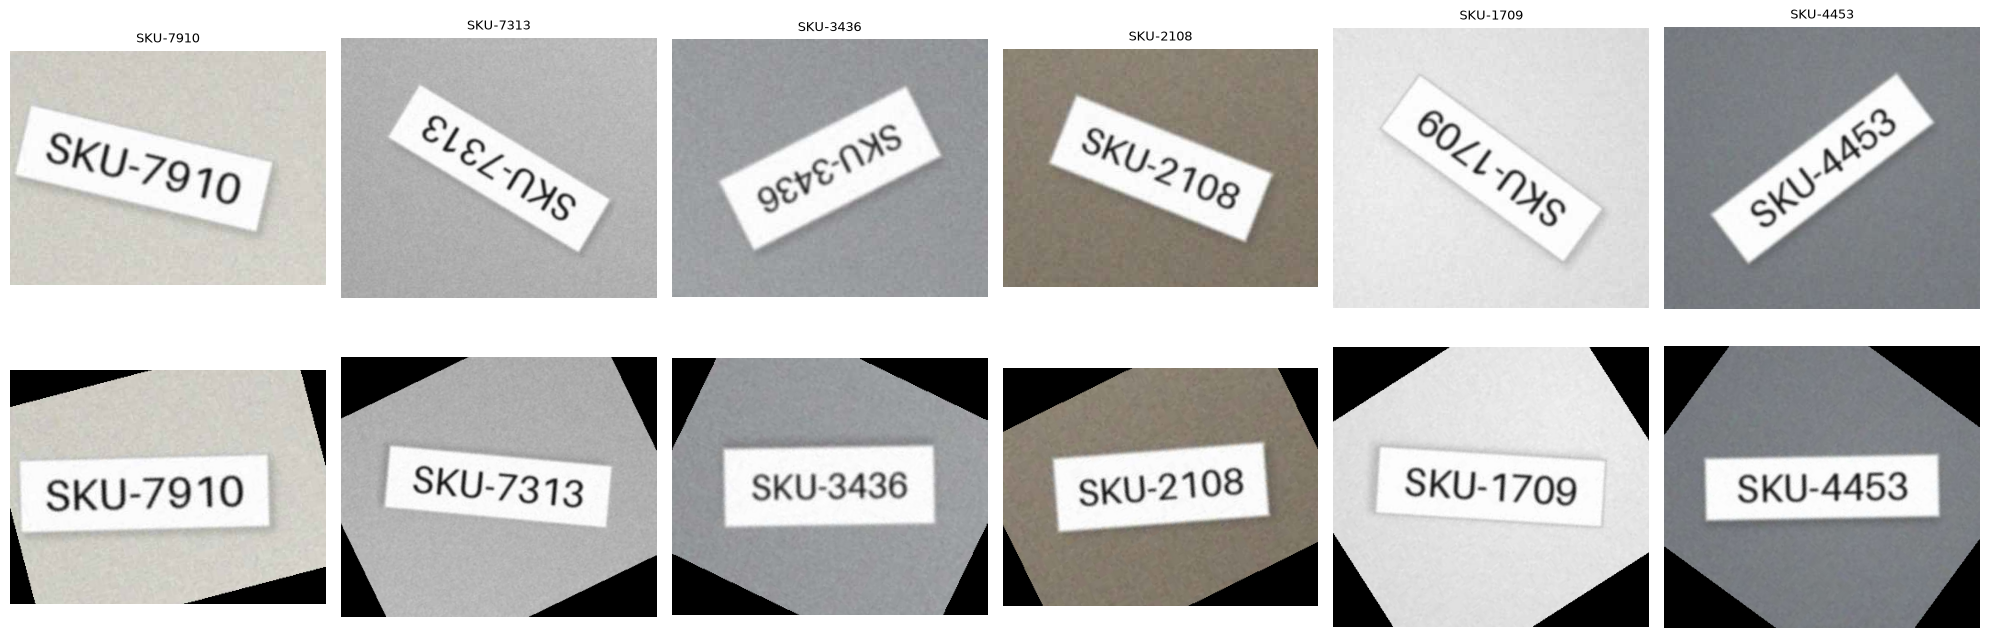

In [7]:
model.eval()
sample = random.sample(val_records, 6)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
with torch.no_grad():
    for col, record in enumerate(sample):
        image = Image.open(settings.RAW_DIR / record["image_path"]).convert("RGB")
        canvas_size = image.size
        bbox = geometry.corners_to_bbox(record["corners_xy"])
        padded = geometry.pad_bbox(bbox, PAD_FRAC, canvas_size)
        crop = image.crop(padded)

        resized = crop.resize((models.OrientationNet.INPUT_SIZE,) * 2, Image.BILINEAR)
        tensor = datasets.image_to_tensor(resized).unsqueeze(0).to(DEVICE)
        sin_v, cos_v = model(tensor)[0].cpu().tolist()
        pred_angle = geometry.sin_cos_to_angle(sin_v, cos_v)

        axes[0, col].imshow(crop)
        axes[0, col].set_title(record["sku"], fontsize=9)
        axes[0, col].axis("off")

        upright = geometry.rotate_upright(crop, pred_angle)
        axes[1, col].imshow(upright)
        axes[1, col].axis("off")

axes[0, 0].set_ylabel("padded crop", fontsize=10)
axes[1, 0].set_ylabel("predicted de-rotation", fontsize=10)
plt.tight_layout()
plt.show()
